# Two-tank mixing case study (up to aggregated causal graph)

This notebook follows the same workflow used in `OWN TUTORIALS/Case CSTR/van_der_vusse_cstr_case_study.ipynb`,
but for a simplified **two-tank cascade** system.

The state equations are:

\[
rac{dC_1}{dt} = rac{F}{V_1}(C_{in} - C_1), \qquad
rac{dC_2}{dt} = rac{F}{V_2}(C_1 - C_2)
\]

where:
- $C_{in}$ is the inlet concentration,
- $C_1$ is the concentration in tank 1,
- $C_2$ is the concentration in tank 2.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tigramite.data_processing as pp
import tigramite.plotting as tp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.robust_parcorr import RobustParCorr


## Data generation and plotting

We simulate multiple realizations of the continuous-time two-tank model using random inlet concentration forcing.
After simulation, trajectories are sampled on a uniform time grid and arranged as a Tigramite `DataFrame`.


In [2]:
# ---------- Model parameters ----------
params = {
    "F": 1.0,    # volumetric flow rate
    "V1": 3.0,   # tank 1 volume
    "V2": 4.5,   # tank 2 volume
}

# Inlet forcing (smoothly varying concentration)
def generate_cin_series(t_eval, rng):
    base = 1.2
    signal = 0.35 * np.sin(2 * np.pi * t_eval / 180.0) + 0.2 * np.sin(2 * np.pi * t_eval / 75.0)
    noise = 0.08 * rng.normal(size=t_eval.shape)
    return np.clip(base + signal + noise, 0.0, None)


def simulate_two_tank(cin_series, params, c1_0, c2_0):
    """Fast explicit simulation on the sampled grid (dt is fixed in the next cell)."""
    F, V1, V2 = params["F"], params["V1"], params["V2"]
    alpha1 = F / V1
    alpha2 = F / V2

    C1 = np.empty_like(cin_series)
    C2 = np.empty_like(cin_series)
    C1[0], C2[0] = c1_0, c2_0

    # Forward-Euler step on the sampled grid: very fast for this linear system.
    for k in range(len(cin_series) - 1):
        C1[k + 1] = C1[k] + dt * alpha1 * (cin_series[k] - C1[k])
        C2[k + 1] = C2[k] + dt * alpha2 * (C1[k] - C2[k])

    return C1, C2


In [3]:
# ---------- Generate multiple trajectories ----------
T = 1200
dt = 1.0
t_eval = np.arange(0, T, dt)

M = 8  # number of independent runs
var_names = ["Cin", "C1", "C2"]
N = len(var_names)

data_dict = {}

for m in range(M):
    rng = np.random.default_rng(100 + m)

    c1_0 = 0.8 + 0.15 * rng.normal()
    c2_0 = 0.7 + 0.15 * rng.normal()

    # Pre-generate forcing once (instead of random calls inside solve_ivp).
    Cin_series = generate_cin_series(t_eval, rng)
    C1_series, C2_series = simulate_two_tank(Cin_series, params=params, c1_0=c1_0, c2_0=c2_0)

    data_dict[m] = np.column_stack([Cin_series, C1_series, C2_series])

# Create Tigramite DataFrame in multiple-run mode
dataframe = pp.DataFrame(data=data_dict, var_names=var_names, analysis_mode="multiple")
print("One run shape (time, variables):", data_dict[0].shape)
print("Number of runs:", len(data_dict))


One run shape (time, variables): (1200, 3)
Number of runs: 8


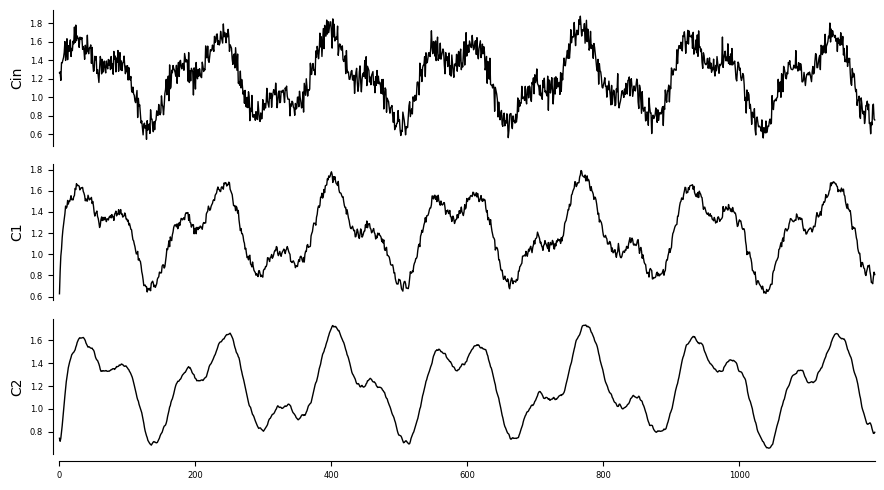

In [4]:
# Quick look at trajectories
# Plot a single representative run to avoid overcrowding.
tp.plot_timeseries(
    dataframe,
    figsize=(9, 5),
    grey_masked_samples=False,
    data_linewidth=1.0,
    selected_dataset=0,
)
plt.show()


## Causal discovery analysis

We apply sliding-window PCMCIplus to identify lagged and contemporaneous causal links.

### Notes on assumptions
- The system is simulated in continuous time, but sampled observations form a discrete-time process suitable for Tigramite.
- We include optional autocorrelation links and physically motivated directed lagged links.


In [5]:
# Maximum time lag
tau_max = 2

# Conditional independence test
cond_ind_test = RobustParCorr(verbosity=0)

# Significance level
pc_alpha = 0.02

# Sliding-window setup
window_step = 120
window_length = 360

# Version-robust link assumptions (no LPCMCI helper):
# We keep Cin (variable 0) exogenous and only allow its own lag as parent.
link_assumptions = {
    0: {(0, -1): 'o?o'},
    1: {(1, -1): 'o?o', (0, -1): '-->'},
    2: {(2, -1): 'o?o', (1, -1): '-->'},
}
for j in link_assumptions:
    print(f"Assumed links of {j}: {link_assumptions[j]}")


Assumed links of 0: {(0, -1): 'o?o'}
Assumed links of 1: {(1, -1): 'o?o', (0, -1): '-->'}
Assumed links of 2: {(2, -1): 'o?o', (1, -1): '-->'}


In [6]:
# Initialize PCMCI class
pcmci = PCMCI(
    dataframe=dataframe,
    cond_ind_test=cond_ind_test,
    verbosity=0,
)

method_args = {
    'tau_min': 0,
    'tau_max': tau_max,
    'pc_alpha': pc_alpha,
    'link_assumptions': link_assumptions,
}

# Run sliding window PCMCIplus
summary_results = pcmci.run_sliding_window_of(
    method='run_pcmciplus',
    method_args=method_args,
    window_step=window_step,
    window_length=window_length,
    conf_lev=0.9,
)

print("Window keys:", summary_results["window_results"].keys())
print("Summary keys:", summary_results["summary_results"].keys())


Window keys: dict_keys(['graph', 'p_matrix', 'val_matrix', 'sepsets', 'ambiguous_triples', 'conf_matrix'])
Summary keys: dict_keys(['most_frequent_links', 'link_frequency', 'val_matrix_mean', 'val_matrix_interval'])


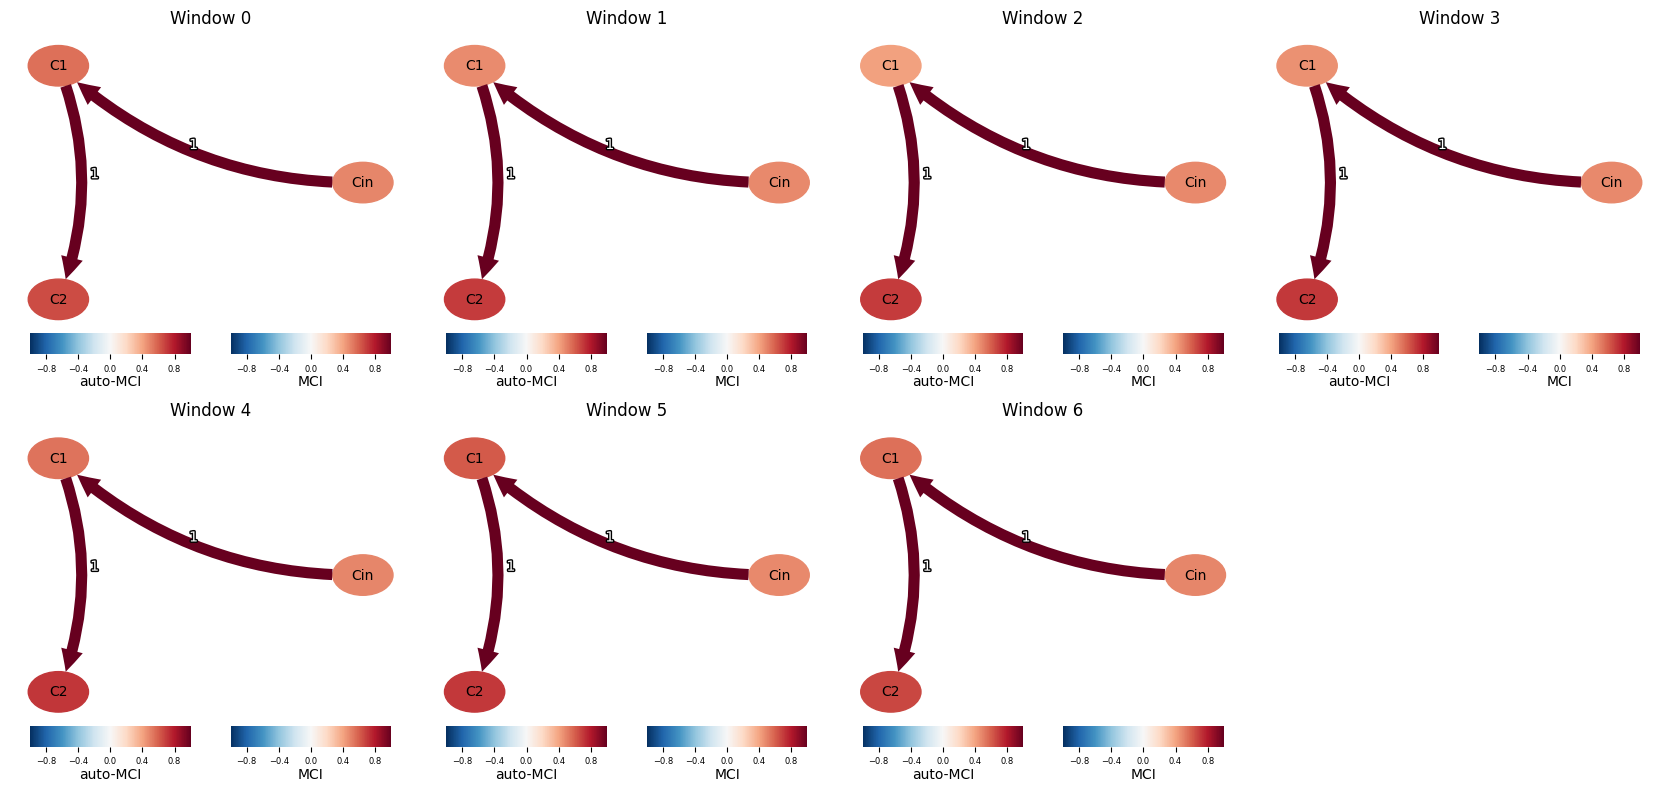

In [7]:
# Plot window-specific causal graphs
graphs = summary_results["window_results"]["graph"]

# Tigramite versions may store either 'val_matrix_mean' or 'val_matrix' per window.
window_vals = summary_results["window_results"].get("val_matrix_mean")
if window_vals is None:
    window_vals = summary_results["window_results"]["val_matrix"]

n_windows = len(graphs)
ncols = min(4, n_windows)
nrows = int(np.ceil(n_windows / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.0 * nrows), squeeze=False)
axes = axes.ravel()

for w, graph_w in enumerate(graphs):
    tp.plot_graph(
        graph=graph_w,
        val_matrix=np.abs(window_vals[w]),
        var_names=var_names,
        link_colorbar_label="MCI",
        node_colorbar_label="auto-MCI",
        fig_ax=(fig, axes[w]),
    )
    axes[w].set_title(f"Window {w}")

for k in range(n_windows, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()


### Aggregated causal graph

As in the CSTR case, we aggregate across windows using the most frequent links and their frequencies.


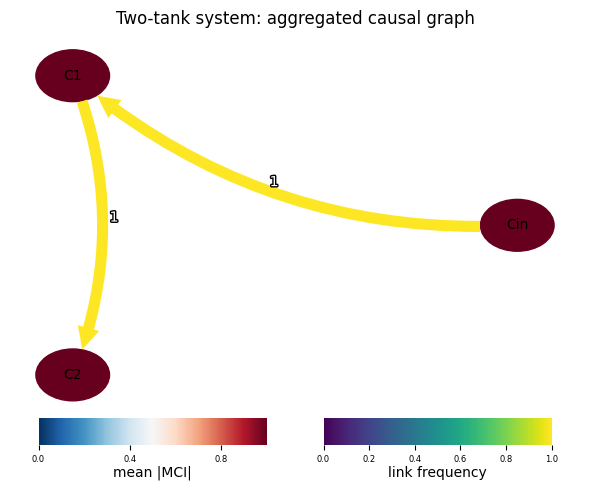

In [8]:
val_tmp = np.abs(summary_results["summary_results"]["val_matrix_mean"])
val_tmp[np.arange(N), np.arange(N), :] = 0.0
cross_max = np.abs(val_tmp).max()

graph = summary_results["summary_results"]["most_frequent_links"]
val_matrix = summary_results["summary_results"]["link_frequency"]

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111)

tp.plot_graph(
    graph=graph,
    val_matrix=val_matrix,
    var_names=var_names,
    vmin_edges=0,
    vmax_edges=1,
    edge_ticks=0.2,
    cmap_edges="viridis",
    vmin_nodes=0,
    vmax_nodes=max(0.05, cross_max),
    link_colorbar_label="link frequency",
    node_colorbar_label="mean |MCI|",
    fig_ax=(fig, ax),
)

ax.set_title("Two-tank system: aggregated causal graph")
plt.tight_layout()
plt.show()
